# Topology optimization of a permanent magnet
In this example the topology of a permanent magnet with magnetization $\vec{M} = (0,0,M_z)$ is optimized to produce a maximum field in z-direction in a single point above the cubic design region.

## Import libraries
Import neccessary libraries and set backend to JAX and pyvisa rendering to static mode.

In [1]:
import jax
import jax.numpy as jnp
import pyvista as pv

import neuralmag as nm

nm.config.backend = "jax"
pv.set_jupyter_backend("static")

2025-05-07 14:34:46 NeuralMag:INFO [NeuralMag] Version 0.9.1
2025-05-07 14:34:47 NeuralMag:INFO [NeuralMag] Backend set to 'jax'.


## Create mesh and state
Create state and set fixed magnetization in z-direction

In [2]:
mesh = nm.Mesh((20, 20, 12), (5e-9, 5e-9, 5e-9))
state = nm.State(mesh)

state.material.Ms = 1.0
state.m = nm.VectorFunction(state).fill((0, 0, 1))

2025-05-07 14:34:47 NeuralMag:INFO [Mesh] 3D, 20 x 20 x 12 (size = 5e-09 x 5e-09 x 5e-09)
2025-05-07 14:34:47 NeuralMag:INFO [NeuralMag] Set default device to 'TFRT_CPU_0'.
2025-05-07 14:34:47 NeuralMag:INFO [NeuralMag] Set default dtype to 'float32'.
2025-05-07 14:34:47 NeuralMag:INFO [State] Running on device: TFRT_CPU_0 (dtype = float32, backend = jax)


## Create dynamic attribute for material density $\rho(\vec{x})$
We create a dynamical attribute `state.rho` that takes a scalar field `state.rho_m` and overrides the upper two layers of cells to be air.

In [3]:
state.rho = (lambda rho_m: rho_m.at[:, :, 10:].set(state.eps), "ccc", ())
state.rho_m = nm.CellFunction(state).fill(1.0)

## Setup demag field
We set up the demag-field class, register it with the state and get a plain function for the demag-field computation with the masked material density `rho_m` as a first parameter.

In [4]:
demag = nm.DemagField().register(state, "demag")
demag_func = state.resolve("h_demag", ["rho_m"])

2025-05-07 14:34:47 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag')
2025-05-07 14:34:47 NeuralMag:INFO [DemagField]: Set up demag tensor


## Define loss function
We define the loss function as negative absolute of the field's z-component in a central point above the design region $\vec{x}_0$
$$J(\rho) = H_z^2(\rho^3 \vec{M}) |_{\vec{x} = \vec{x}_0}$$
and compute the gradient function.

In [5]:
def loss(rho):
    return -demag_func(rho**3)[10, 10, 12, 2] ** 2


grad_loss = jax.grad(loss)

## Optimization loop
Perform the optimization loop by updating `rho_m` with the negative gradient and clip the values of `rho_m` to the interval [eps, 1].

In [6]:
learning_rate = 1e3

for i in range(100):
    grad = grad_loss(state.rho_m.tensor)
    state.rho_m.tensor = jnp.clip(
        state.rho_m.tensor - grad * learning_rate, state.eps, 1.0
    )

## Write result and visualize

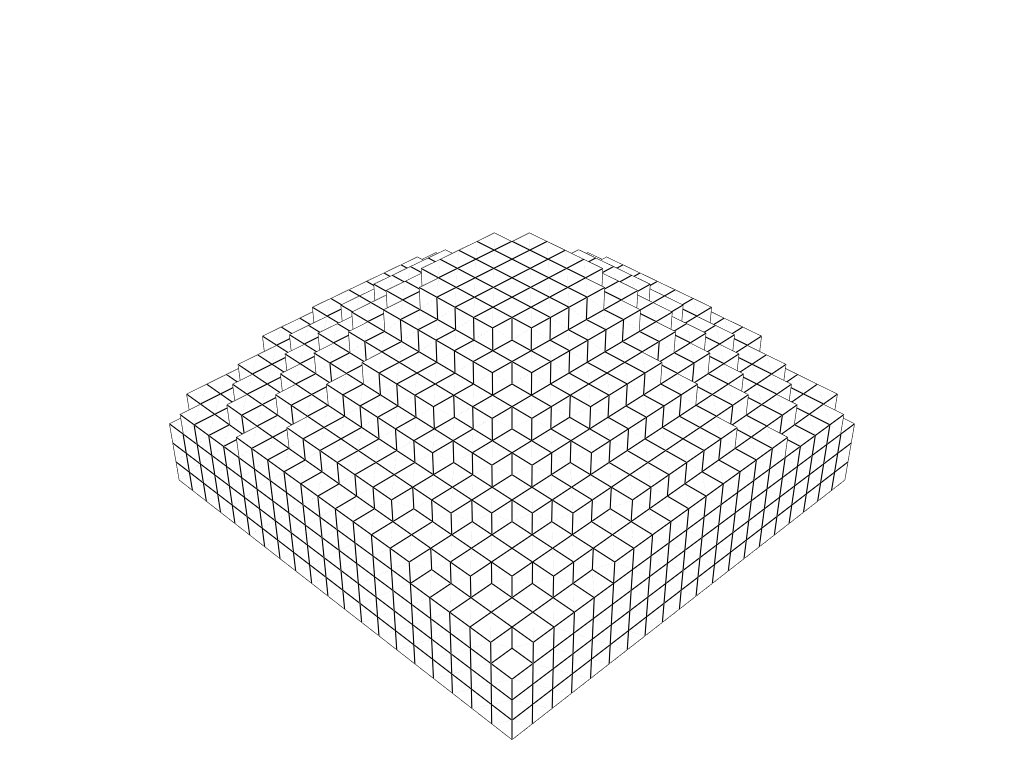

In [7]:
state.write_vti("rho", "rho.vti")

mesh = pv.read("rho.vti")
thresholded_mesh = mesh.threshold(value=0.5, scalars="rho")

plotter = pv.Plotter()
plotter.add_mesh(
    thresholded_mesh,
    color="white",
    lighting=False,
    smooth_shading=False,
    show_edges=True,
)
plotter.show()